# From crystal to counted atoms

This notebook walks the full pipeline: simulate a chosen material, degrade
the image with dose-limited noise and scan drift, detect the atomic columns,
refine them to sub-pixel accuracy, and score the result against the exact
ground truth. Everything runs on CPU in under a minute using the committed
model weights.

Run it from the repository root so the relative paths to `models/` and
`data/` resolve.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from atomfinder import (
    preset_config, simulate_image,
    detect_log, detect_ncc, peaks_from_heatmap,
    UNet, predict_heatmap,
    refine_com, refine_gaussian,
    match_positions, per_species_recall, filter_margin,
    load_image, crop_to_multiple,
)
from atomfinder.metrics import margin_mask

rng = np.random.default_rng(0)

## 1. Simulate a material

The simulator builds a 2D projected crystal from a preset (here an MoS2
monolayer), gives every column a HAADF weight proportional to the sum of
Z^1.7 over its atoms, blurs with a Gaussian probe, and tracks the exact
position of every column. Mo columns are bright; S2 columns carry about 39%
of the Mo weight, and 8% of them lose one sulfur atom (a monovacancy), which
halves their intensity.

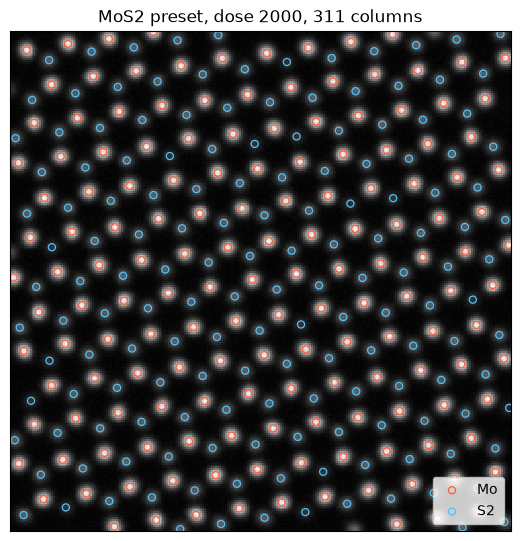

In [2]:
config = preset_config("mos2", size=256, dose=2000.0, rotation_deg=8.0)
clean = simulate_image(config, np.random.default_rng(42))

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.imshow(clean.image, cmap="gray", interpolation="nearest")
names = clean.species_names
for sid, (name, color) in enumerate(zip(names, ("#ff5c39", "#4dc3ff"))):
    sel = clean.positions[clean.species == sid]
    ax.scatter(sel[:, 1], sel[:, 0], s=26, facecolors="none",
               edgecolors=color, linewidths=0.9, label=name)
ax.legend(loc="lower right")
ax.set_title(f"MoS2 preset, dose 2000, {len(clean.positions)} columns")
ax.set_xticks([]); ax.set_yticks([])
plt.show()

## 2. Make it hard: dose and drift

Real experiments are dose-limited (beam-sensitive samples) and the sample
drifts slowly while the scan rasters down the frame. Both are single knobs
here, and the ground truth is shifted through the same distortions.

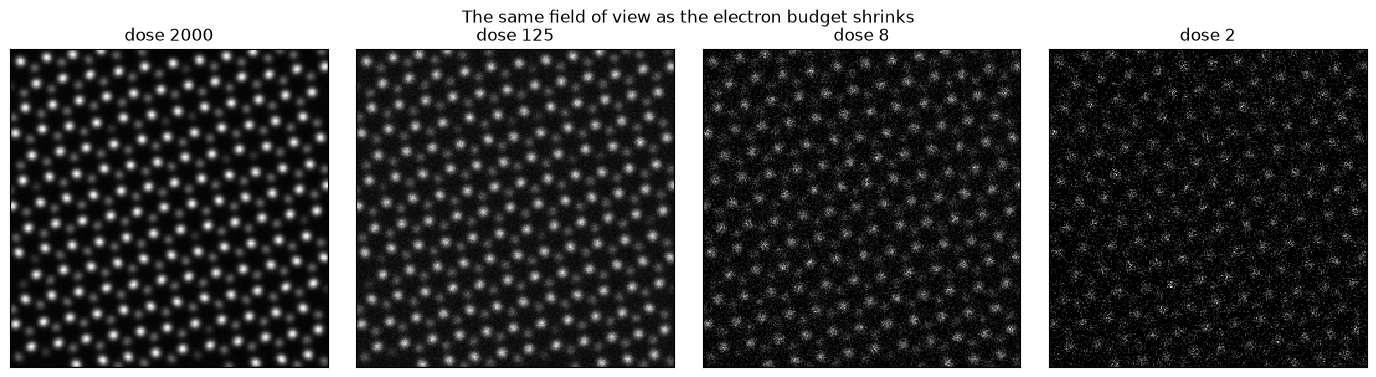

In [3]:
doses = [2000.0, 125.0, 8.0, 2.0]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, dose in zip(axes, doses):
    result = simulate_image(
        preset_config("mos2", size=256, dose=dose, rotation_deg=8.0),
        np.random.default_rng(42),
    )
    ax.imshow(result.image, cmap="gray", interpolation="nearest")
    ax.set_title(f"dose {dose:g}")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("The same field of view as the electron budget shrinks")
plt.tight_layout(); plt.show()

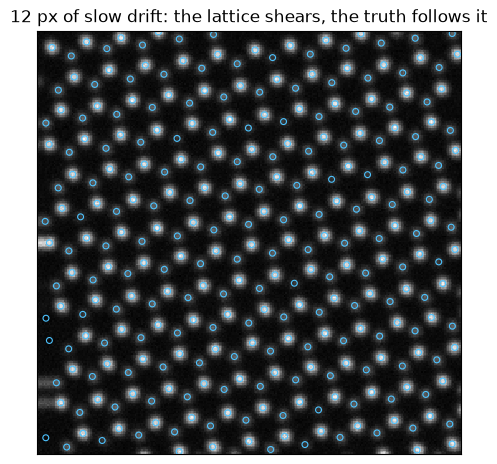

In [4]:
drifted = simulate_image(
    preset_config("mos2", size=256, dose=500.0, rotation_deg=8.0,
                  drift_px=12.0, drift_angle_deg=20.0),
    np.random.default_rng(42),
)
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(drifted.image, cmap="gray", interpolation="nearest")
ax.scatter(drifted.positions[:, 1], drifted.positions[:, 0], s=18,
           facecolors="none", edgecolors="#4dc3ff", linewidths=0.8)
ax.set_title("12 px of slow drift: the lattice shears, the truth follows it")
ax.set_xticks([]); ax.set_yticks([])
plt.show()

## 3. Detect

Three detectors on the same dose-8 image: the Laplacian-of-Gaussian
baseline, normalised cross-correlation against a Gaussian template, and the
committed segmentation U-Net (29,641 parameters, trained only on simulation).

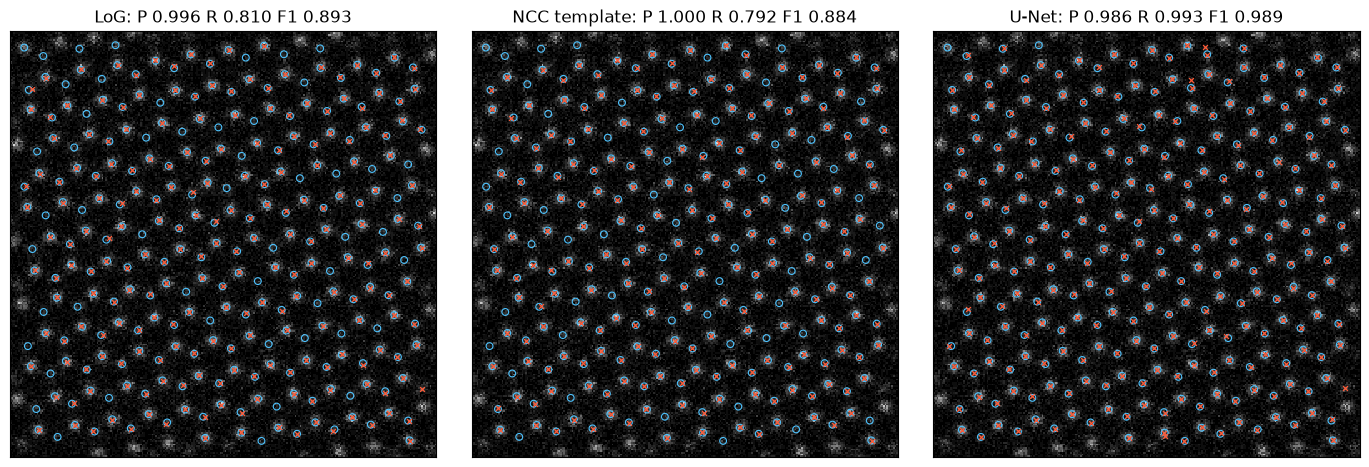

In [5]:
noisy = simulate_image(
    preset_config("mos2", size=256, dose=8.0, rotation_deg=8.0),
    np.random.default_rng(42),
)
model = UNet()
model.load_state_dict(torch.load("models/unet_seg.pt", weights_only=True))

detections = {
    "LoG": detect_log(noisy.image, sigma=noisy.config.probe_sigma),
    "NCC template": detect_ncc(noisy.image, sigma=noisy.config.probe_sigma),
    "U-Net": peaks_from_heatmap(predict_heatmap(model, noisy.image)),
}

MARGIN, TOL = 8.0, 4.0
true = filter_margin(noisy.positions, noisy.image.shape, MARGIN)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, (label, peaks) in zip(axes, detections.items()):
    refined = refine_com(noisy.image, peaks)
    pred = filter_margin(refined, noisy.image.shape, MARGIN)
    res = match_positions(true, pred, TOL)
    ax.imshow(noisy.image, cmap="gray", interpolation="nearest")
    ax.scatter(true[:, 1], true[:, 0], s=24, facecolors="none",
               edgecolors="#4dc3ff", linewidths=0.8)
    ax.scatter(pred[:, 1], pred[:, 0], s=12, marker="x", c="#ff5c39", lw=0.9)
    ax.set_title(f"{label}: P {res.precision:.3f} R {res.recall:.3f} F1 {res.f1:.3f}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

The faint S2 columns are where detectors differ. Per-species recall makes
that visible:

In [6]:
rows = []
for label, peaks in detections.items():
    refined = refine_com(noisy.image, peaks)
    pred = filter_margin(refined, noisy.image.shape, MARGIN)
    tmask = margin_mask(noisy.positions, noisy.image.shape, MARGIN)
    rec = per_species_recall(noisy.positions[tmask], noisy.species[tmask],
                             noisy.species_names, pred, TOL)
    rows.append((label, rec["Mo"], rec["S2"]))
print(f"{'method':14s} {'Mo recall':>10s} {'S2 recall':>10s}")
for label, mo, s2 in rows:
    print(f"{label:14s} {mo:10.3f} {s2:10.3f}")

method          Mo recall  S2 recall
LoG                 0.993      0.630
NCC template        0.993      0.594
U-Net               0.993      0.993


## 4. Refine to sub-pixel accuracy

Detection gives integer pixels. Quantitative STEM needs better: iterative
centre of mass is fast; a 2D Gaussian least-squares fit is the field
standard. Starting both from the truth rounded to whole pixels isolates the
refiner error itself.

In [7]:
bright = simulate_image(
    preset_config("mos2", size=256, dose=500.0, rotation_deg=8.0),
    np.random.default_rng(7),
)
start = np.round(bright.positions)
for label, refiner in [("integer pixels", None), ("centre of mass", refine_com),
                       ("2D Gaussian fit", refine_gaussian)]:
    pts = start if refiner is None else refiner(bright.image, start)
    keep = margin_mask(pts, bright.image.shape, MARGIN)
    err = np.sqrt(np.mean(np.sum((pts[keep] - bright.positions[keep]) ** 2, axis=1)))
    print(f"{label:16s} RMSE {err:.3f} px")

integer pixels   RMSE 0.404 px
centre of mass   RMSE 0.185 px


2D Gaussian fit  RMSE 0.070 px


## 5. A real image, and the domain gap

`data/real/al_001_haadf_wikimedia.png` is an experimental HAADF-STEM image
of aluminium along [001] (Matheustunes, Wikimedia Commons, CC BY-SA 4.0).
Two things differ from the simulation immediately: a burned-in scale bar
(cropped below), and much coarser sampling, with columns roughly 40 px apart
instead of ~14. Matching the sampling by downsampling 3x is the first, and
biggest, domain-adaptation step.

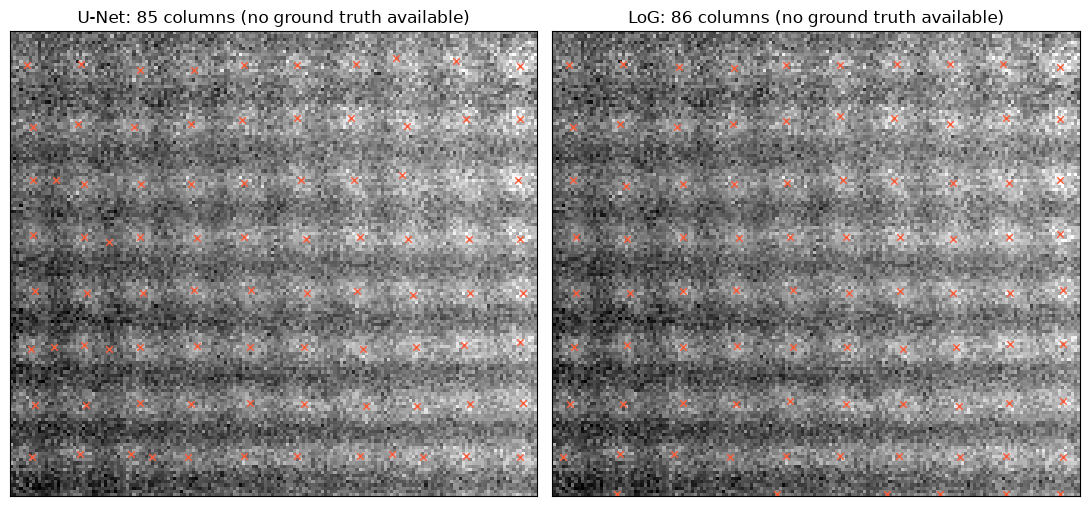

In [8]:
real = load_image("data/real/al_001_haadf_wikimedia.png")[:448, :]
small = crop_to_multiple(real[::3, ::3])

real_peaks = peaks_from_heatmap(predict_heatmap(model, small), threshold=0.4)
real_log = detect_log(small, sigma=3.5, threshold_rel=0.30)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (label, peaks) in zip(axes, [("U-Net", real_peaks), ("LoG", real_log)]):
    ax.imshow(small, cmap="gray", interpolation="nearest")
    if len(peaks):
        peaks = refine_com(small, peaks)
        ax.scatter(peaks[:, 1], peaks[:, 0], s=22, marker="x", c="#ff5c39", lw=1.0)
    ax.set_title(f"{label}: {len(peaks)} columns (no ground truth available)")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

There is no ground truth for the real image, so this is a qualitative check
only: detections should sit on the visible lattice and nowhere else. Expect
the U-Net to be less confident here than on simulation. That gap
(contamination, amorphous edges, non-Poisson detector noise, unseen pixel
sampling) is exactly what the model card documents, and fine-tuning on a few
labelled experimental patches is the standard way to close it.

## Where to go next

- `atomfinder benchmark configs/dose_sweep.yaml` reruns the full dose story.
- `configs/materials.yaml` scores every detector on all four presets.
- `docs/api.md` documents the full API surface.